# Chart Manipulation

## What is Chart Manipulation?

A graph can communicate information far faster than a table of numbers because humans naturally process visual patterns more efficiently than raw numerical values.

However, this same strength creates a major weakness. People often trust what they see without verifying how the visualization was constructed.

As a result, a graph can create a misleading impression even when the underlying data is completely accurate. This phenomenon is known as **chart manipulation**.

Chart manipulation is the process of designing a graph or visualization in a way that causes the audience to perceive the data differently from what the actual numerical values indicate. The data itself may remain completely unchanged.


## Common Types of Chart Manipulation

1. Truncated Axis
2. Dual-Axis Scaling
3. Inverted Axis
4. Misleading Logarithmic Scale





### Truncated Axis

A truncated axis is a graphing technique in which an axis, usually the Y-axis, starts at a value other than its natural baseline (typically zero). By removing a portion of the scale, the chart changes the visual representation of differences between data points without changing the underlying data itself.

The word **truncated** means "cut short" or "partially removed." In data visualization, this means part of the axis has been intentionally omitted.

A truncated axis can be used for legitimate reasons, such as focusing attention on small variations in scientific measurements. However, it can also be used to exaggerate changes, making small differences appear dramatically larger than they actually are.

The key danger of a truncated axis is that human beings naturally compare the visible height or length of graphical elements rather than calculating the actual numerical differences. As a result, viewers often perceive a much larger change than what the data truly indicates.







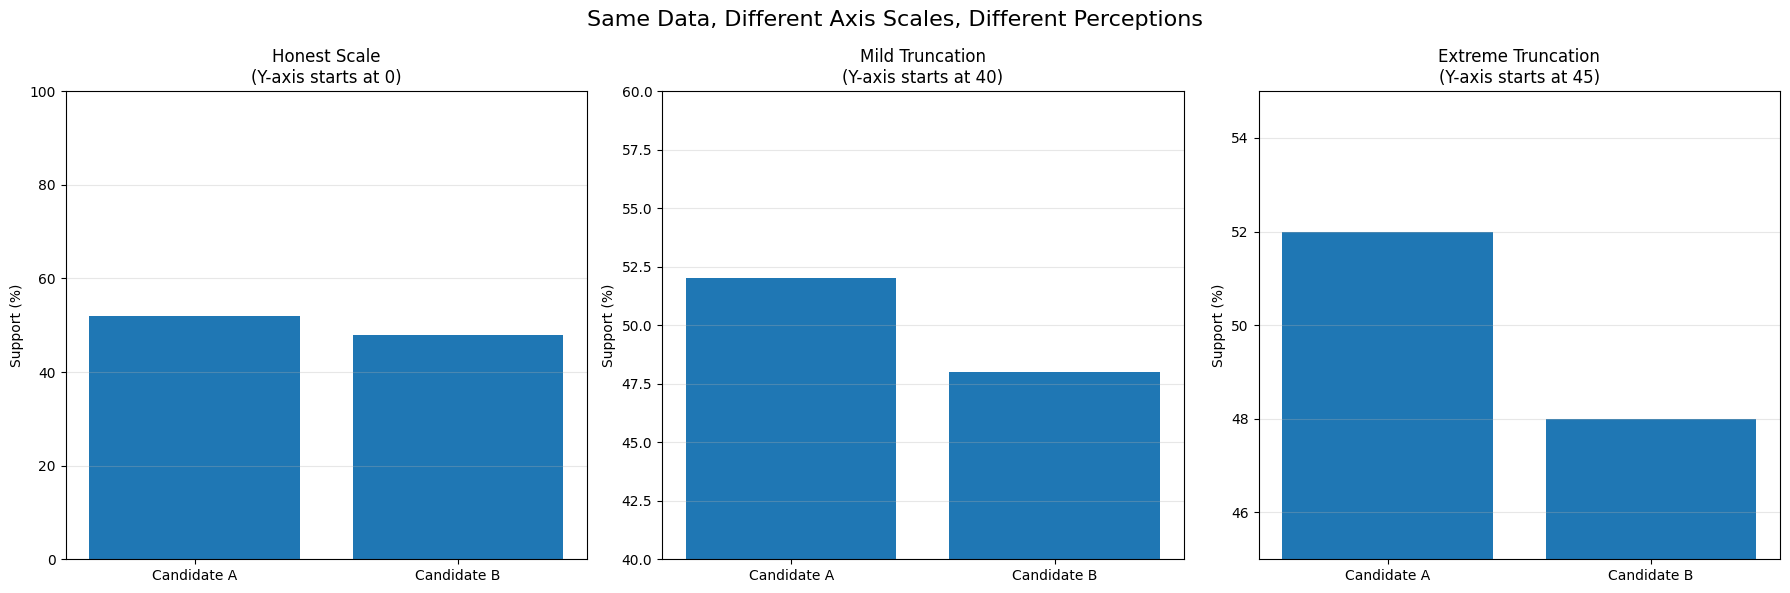

In [ ]:
import matplotlib.pyplot as plt

# Election polling data
candidates = ["Candidate A", "Candidate B"]
support = [52, 48]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# -----------------------------
# Chart 1: Honest Scale
# -----------------------------
axes[0].bar(candidates, support)

axes[0].set_ylim(0, 100)

axes[0].set_title( "Honest Scale\n(Y-axis starts at 0)" )

axes[0].set_ylabel( "Support (%)" )

axes[0].grid(
    axis="y",
    alpha=0.3
)

# -----------------------------
# Chart 2: Mild Truncation
# -----------------------------
axes[1].bar(candidates, support)

axes[1].set_ylim(40, 60)

axes[1].set_title(
    "Mild Truncation\n(Y-axis starts at 40)"
)

axes[1].set_ylabel(
    "Support (%)"
)

axes[1].grid(
    axis="y",
    alpha=0.3
)

# -----------------------------
# Chart 3: Extreme Truncation
# -----------------------------
axes[2].bar(candidates, support)

axes[2].set_ylim(45, 55)

axes[2].set_title(
    "Extreme Truncation\n(Y-axis starts at 45)"
)

axes[2].set_ylabel(
    "Support (%)"
)

axes[2].grid(
    axis="y",
    alpha=0.3
)

plt.suptitle(
    "Same Data, Different Axis Scales, Different Perceptions",
    fontsize=16
)

plt.tight_layout()

plt.show()

Problem : The axis starts above zero.

Example:

```javascript
scales: {
  y: {
    min: 828.46,
    beginAtZero: false
  }
}
```

This exaggerates differences because viewers compare visible heights rather than raw values.

---

## Minimal Fix

```javascript
scales: {
  y: {
    min: 0
  }
}
```


### Dual-Axis Scaling


A dual-axis chart is a data visualization that displays two different variables on the same graph using two separate Y-axes.

Typically:

- One Y-axis appears on the left side.
- One Y-axis appears on the right side.
- Both variables share the same X-axis.

This allows data with different units, magnitudes, or scales to be displayed within a single visualization.





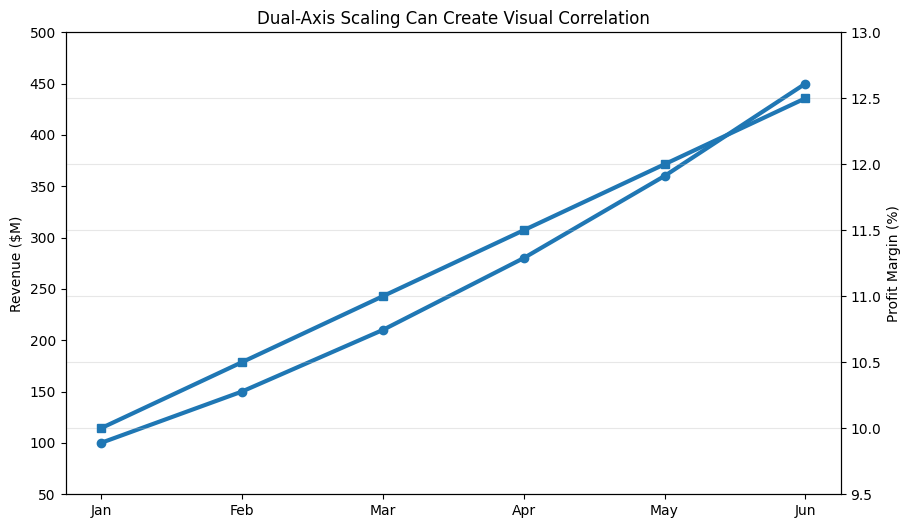

In [3]:
import matplotlib.pyplot as plt

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun"]

revenue = [100, 150, 210, 280, 360, 450]
profit_margin = [10, 10.5, 11, 11.5, 12, 12.5]

fig, ax1 = plt.subplots(
    figsize=(10, 6)
)

# Revenue
ax1.plot(
    months,
    revenue,
    marker="o",
    linewidth=3
)

ax1.set_ylabel(
    "Revenue ($M)"
)

# Manipulated scale
ax1.set_ylim(
    50,
    500
)

# Second axis
ax2 = ax1.twinx()

ax2.plot(
    months,
    profit_margin,
    marker="s",
    linewidth=3
)

# Manipulated scale
ax2.set_ylim(
    9.5,
    13
)

ax2.set_ylabel(
    "Profit Margin (%)"
)

plt.title(
    "Dual-Axis Scaling Can Create Visual Correlation"
)

plt.grid(
    alpha=0.3
)

plt.show()

Problem

Two Y-axes use different scales.

Example:

```javascript
scales: {
  y: {
    position: "left"
  },

  y1: {
    position: "right"
  }
}
```

This can make unrelated variables appear strongly correlated.

---

## Minimal Fix

Place both datasets on the same Y-axis.

---

## Before

```javascript
datasets: [
  {
    label: "Revenue",
    yAxisID: "y"
  },
  {
    label: "Profit",
    yAxisID: "y1"
  }
]
```


---

### Inverted Axis 


Problem

The axis is reversed.

Example:

```javascript
y: {
  reverse: true
}
```

Large values appear lower than small values.

This reverses normal interpretation.

---

## Minimal Fix

Disable reversal.

---

## Before

```javascript
y: {
  reverse: true
}
```

---

## After

```javascript
y: {
  reverse: false
}
```

or simply:

```javascript
y: {}
```

---

## Why This Works

Values increase upward again.

The chart follows standard visual conventions.


---

### Misleading Logarithmic Scale 



## General Formula

The fundamental structure of a distortion ratio is:

$$
       Distortion Ratio 
       = \frac {
                     Visual\ Relationship
              }
              {
                     Actual\ Relationship
              }
$$